This colab creates 3 different datasets:

**balanced_df** = using every single song per decade, downsampled randomly until 20% hit rate

**balanced_df_2000** = downsampled randomly but until there's only 2000 songs and also 20% hit rate

**balanced_1700_unPOP_df** = downsampled by only keeping the non-hits that have a 0 of popularity spotify score but until there's only 1700 songs and also 20% hit rate. 1700 was chosen because there weren't enough songs in the 60s.

In [ ]:
!pip install opendatasets -q

import opendatasets as od
od.download('https://www.kaggle.com/datasets/serkantysz/550k-spotify-songs-audio-lyrics-and-genres?select=songs.csv')
od.download('https://www.kaggle.com/datasets/dhruvildave/billboard-the-hot-100-songs')

Skipping, found downloaded files in "./550k-spotify-songs-audio-lyrics-and-genres" (use force=True to force download)
Skipping, found downloaded files in "./billboard-the-hot-100-songs" (use force=True to force download)


In [ ]:
import pandas as pd
import re

songs_df   = pd.read_csv('/content/550k-spotify-songs-audio-lyrics-and-genres/songs.csv')
charts_df  = pd.read_csv('/content/billboard-the-hot-100-songs/charts.csv')

# showing all features in the dataset
print('songs_df columns:', songs_df.columns.tolist())
print('songs_df shape:  ', songs_df.shape)

songs_df columns: ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres']
songs_df shape:   (550622, 24)


In [ ]:
# printing # of songs per decade
songs_df['decade'] = (songs_df['year'] // 10 * 10).astype(str) + 's'
print(songs_df.groupby('decade').size().to_string())

decade
1900s        30
1910s         3
1920s       156
1930s       288
1940s       437
1950s      4119
1960s     11344
1970s     17570
1980s     20729
1990s     42913
2000s    162161
2010s    225362
2020s     65510


In [ ]:
import ast

def normalize_text(text):
    if pd.isna(text): return ''
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

# keeping first artist
def clean_artist_name(artist):
    for sep in [' featuring ', ' feat. ', ' feat ', ' ft. ', ' ft ', ' x ', ' & ', ' with ']:
        artist = artist.lower().split(sep)[0]
    return artist.strip()

# keeping only the first artist
def get_primary_artist(artists_str):
    try:
        artists_list = ast.literal_eval(artists_str)
        return normalize_text(artists_list[0])
    except:
        return clean_artist_name(normalize_text(str(artists_str)))

#setting up the normalized song titles and artist names for matching in the next section
songs_df['song_normalized']   = songs_df['name'].apply(normalize_text)
songs_df['artist_normalized'] = songs_df['artists'].apply(get_primary_artist)

charts_df['song_normalized']   = charts_df['song'].apply(normalize_text)
charts_df['artist_normalized'] = charts_df['artist'].apply(lambda x: clean_artist_name(normalize_text(x)))

In [ ]:
# creating the is_hit label feature to songs dataframe
# a song is a hit if it ever reached top 10, matched on song + artist name
top10 = charts_df[charts_df['rank'] <= 10][['song_normalized', 'artist_normalized']].drop_duplicates()
top10['is_hit'] = 1

songs_df = songs_df.merge(top10, on=['song_normalized', 'artist_normalized'], how='left')
songs_df['is_hit'] = songs_df['is_hit'].fillna(0).astype(int)

print(f"Total songs:  {len(songs_df):,}")
print(f"Hits (top10): {songs_df['is_hit'].sum():,}")
print(f"Overall hit rate: {songs_df['is_hit'].mean():.1%}")

Total songs:  550,622
Hits (top10): 7,292
Overall hit rate: 1.3%


In [ ]:
# checking how many hits we have per decade in a percentage (hint: not a lot!)
decade_stats = songs_df.groupby('decade')['is_hit'].agg(
    total='count',
    hits='sum'
)
decade_stats['hit_rate'] = (decade_stats['hits'] / decade_stats['total']).map('{:.1%}'.format)
print(decade_stats[decade_stats.index >= '1960s'].to_string())

         total  hits hit_rate
decade                       
1960s    11344   437     3.9%
1970s    17570   604     3.4%
1980s    20729   796     3.8%
1990s    42913   850     2.0%
2000s   162161  1821     1.1%
2010s   225362  2128     0.9%
2020s    65510   620     0.9%


In [ ]:
# @title Only using non-hits that are popularity 0 metric

print(songs_df.columns.tolist())
songs_df_unPop = songs_df[~((songs_df['popularity'] > 0) & (songs_df['is_hit'] == 0))]

['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'decade', 'song_normalized', 'artist_normalized', 'is_hit']


In [ ]:
# checking how many hits we have per decade in a percentage after taking out non-zero non_hit songs
decade_stats = songs_df_unPop.groupby('decade')['is_hit'].agg(
    total='count',
    hits='sum'
)
decade_stats['hit_rate'] = (decade_stats['hits'] / decade_stats['total']).map('{:.1%}'.format)
print(decade_stats[decade_stats.index >= '1960s'].to_string())

        total  hits hit_rate
decade                      
1960s    1798   437    24.3%
1970s    3496   604    17.3%
1980s    4212   796    18.9%
1990s   10536   850     8.1%
2000s   43777  1821     4.2%
2010s   70817  2128     3.0%
2020s   18636   620     3.3%


In [ ]:
# @title Downsample 1700 - downsample only with 0 popularity songs for non-hits
# downsampling to 20% hit rate, at only 2000 songs
balanced_2000_decades = []

for decade, group in songs_df_unPop.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_hits = 340
    target_non_hits = 340 * 4
    hits_sampled = hits.sample(n=target_hits, random_state=42)
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced_2000 = pd.concat([hits_sampled, non_hits_sampled])
    balanced_2000_decades.append(balanced_2000)
    print(f"{decade}: {len(hits_sampled)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits_sampled)/len(balanced_2000):.1%}")

balanced_1700_unPOP_df = pd.concat(balanced_2000_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_1700_unPOP_df):,} songs")

1960s: 340 hits, 1360 non-hits, hit rate: 20.0%
1970s: 340 hits, 1360 non-hits, hit rate: 20.0%
1980s: 340 hits, 1360 non-hits, hit rate: 20.0%
1990s: 340 hits, 1360 non-hits, hit rate: 20.0%
2000s: 340 hits, 1360 non-hits, hit rate: 20.0%
2010s: 340 hits, 1360 non-hits, hit rate: 20.0%
2020s: 340 hits, 1360 non-hits, hit rate: 20.0%

Total: 11,900 songs


In [ ]:
# @title Downsample 2000 - random Downsample
# downsampling to 20% hit rate, at only 2000 songs
balanced_2000_decades = []

for decade, group in songs_df.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_hits = 400
    target_non_hits = 400 * 4
    hits_sampled = hits.sample(n=target_hits, random_state=42)
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced_2000 = pd.concat([hits_sampled, non_hits_sampled])
    balanced_2000_decades.append(balanced_2000)
    print(f"{decade}: {len(hits_sampled)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits_sampled)/len(balanced_2000):.1%}")

balanced_2000_df = pd.concat(balanced_2000_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_2000_df):,} songs")

1960s: 400 hits, 1600 non-hits, hit rate: 20.0%
1970s: 400 hits, 1600 non-hits, hit rate: 20.0%
1980s: 400 hits, 1600 non-hits, hit rate: 20.0%
1990s: 400 hits, 1600 non-hits, hit rate: 20.0%
2000s: 400 hits, 1600 non-hits, hit rate: 20.0%
2010s: 400 hits, 1600 non-hits, hit rate: 20.0%
2020s: 400 hits, 1600 non-hits, hit rate: 20.0%

Total: 14,000 songs


In [ ]:
# @title Downsample Full
# downsampling to 20% hit rate
balanced_decades = []

for decade, group in songs_df.groupby('decade'):
    if decade < '1960s':
        continue
    hits = group[group['is_hit'] == 1]
    non_hits = group[group['is_hit'] == 0]

    # * 4 because of hit rate
    target_non_hits = min(len(hits) * 4, len(non_hits))
    non_hits_sampled = non_hits.sample(n=target_non_hits, random_state=42)

    balanced = pd.concat([hits, non_hits_sampled])
    balanced_decades.append(balanced)
    print(f"{decade}: {len(hits)} hits, {len(non_hits_sampled)} non-hits, hit rate: {len(hits)/len(balanced):.1%}")

balanced_df = pd.concat(balanced_decades).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nTotal: {len(balanced_df):,} songs")

1960s: 437 hits, 1748 non-hits, hit rate: 20.0%
1970s: 604 hits, 2416 non-hits, hit rate: 20.0%
1980s: 796 hits, 3184 non-hits, hit rate: 20.0%
1990s: 850 hits, 3400 non-hits, hit rate: 20.0%
2000s: 1821 hits, 7284 non-hits, hit rate: 20.0%
2010s: 2128 hits, 8512 non-hits, hit rate: 20.0%
2020s: 620 hits, 2480 non-hits, hit rate: 20.0%

Total: 36,280 songs


In [ ]:
print(balanced_2000_df.columns.tolist())

['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year', 'genre', 'popularity', 'total_artist_followers', 'avg_artist_popularity', 'artist_ids', 'niche_genres', 'decade', 'song_normalized', 'artist_normalized', 'is_hit']


In [ ]:
balanced_2000_df = balanced_2000_df[['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']]
balanced_df = balanced_df[['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']]
balanced_1700_unPOP_df = balanced_1700_unPOP_df[['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']]

In [ ]:
print(balanced_2000_df.columns.tolist())

['id', 'song_normalized', 'artist_normalized', 'lyrics', 'is_hit', 'decade']


BELOW IS THE CODE TO LOAD, TRAIN, and EVALUATE

In [ ]:
!pip install transformers datasets evaluate -q


import os
os.environ["WANDB_DISABLED"] = "true"

import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding
from evaluate import load

In [ ]:
# @title BERT!

# --- Load tokenizer & model ---
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# --- Convert balanced_2000_df to HuggingFace Dataset ---
df = balanced_2000_df[["lyrics", "is_hit"]].dropna(subset=["lyrics"]).copy()
df = df.rename(columns={"lyrics": "text", "is_hit": "label"})

dataset = Dataset.from_pandas(df, preserve_index=False)
dataset = dataset.train_test_split(test_size=0.2, seed=42)

# --- Tokenize ---
def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True)

tokenized_train = dataset["train"].map(preprocess_function)
tokenized_test  = dataset["test"].map(preprocess_function)

# --- Metrics ---
def compute_metrics(eval_pred):
    load_accuracy = load("accuracy")
    load_f1 = load("f1")
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = load_accuracy.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = load_f1.compute(predictions=predictions, references=labels)["f1"]
    return {"accuracy": accuracy, "f1": f1}

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/11200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2800 [00:00<?, ? examples/s]

In [ ]:
from evaluate import load as load_metric

def compute_metrics(eval_pred):
    load_accuracy  = load_metric("accuracy")
    load_f1        = load_metric("f1")
    load_precision = load_metric("precision")
    load_recall    = load_metric("recall")

    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy  = load_accuracy.compute( predictions=predictions, references=labels)["accuracy"]
    f1        = load_f1.compute(       predictions=predictions, references=labels)["f1"]
    precision = load_precision.compute(predictions=predictions, references=labels)["precision"]
    recall    = load_recall.compute(   predictions=predictions, references=labels)["recall"]

    return {"accuracy": accuracy, "f1": f1, "precision": precision, "recall": recall}


In [ ]:
from transformers import TrainingArguments, DataCollatorWithPadding

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
//results = {}

for decade, group in balanced_2000_df.groupby("decade"):
    print(f"\n========== {decade} ==========")

    df = group[["lyrics", "is_hit"]].dropna(subset=["lyrics"]).copy()
    df = df.rename(columns={"lyrics": "text", "is_hit": "label"})

    dataset = Dataset.from_pandas(df, preserve_index=False)
    dataset = dataset.train_test_split(test_size=0.2, seed=42)

    tokenized_train = dataset["train"].map(preprocess_function)
    tokenized_test  = dataset["test"].map(preprocess_function)

    model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    metrics = trainer.evaluate()
    results[decade] = metrics
    print(f"{decade} → {metrics}")

print("\n===== All Decade Results =====")
for decade, m in results.items():
    print(f"{decade}: accuracy={m['eval_accuracy']:.3f}, f1={m['eval_f1']:.3f}")


========== 1960s ==========


Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.347824,0.862500,0.421053,0.869565,0.277778
2,No log,0.312022,0.867500,0.658065,0.614458,0.708333
3,No log,0.309712,0.875000,0.662162,0.644737,0.680556


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2020s → {'eval_loss': 0.30971235036849976, 'eval_accuracy': 0.875, 'eval_f1': 0.6621621621621622, 'eval_precision': 0.6447368421052632, 'eval_recall': 0.6805555555555556, 'eval_runtime': 8.722, 'eval_samples_per_second': 45.861, 'eval_steps_per_second': 2.866, 'epoch': 3.0}

===== All Decade Results =====
1960s: accuracy=0.800, f1=0.149
1970s: accuracy=0.802, f1=0.347
1980s: accuracy=0.782, f1=0.065
1990s: accuracy=0.838, f1=0.552
2000s: accuracy=0.825, f1=0.470
2010s: accuracy=0.833, f1=0.579
2020s: accuracy=0.875, f1=0.662


In [ ]:
print("\n===== All Decade Results =====")
for decade, m in results.items():
    print(f"{decade}: accuracy={m['eval_accuracy']:.3f}, f1={m['eval_f1']:.3f}")


===== All Decade Results =====
1960s: accuracy=0.800, f1=0.149
1970s: accuracy=0.802, f1=0.347
1980s: accuracy=0.782, f1=0.065
1990s: accuracy=0.838, f1=0.552
2000s: accuracy=0.825, f1=0.470
2010s: accuracy=0.833, f1=0.579
2020s: accuracy=0.875, f1=0.662


In [ ]:
# Precision and Recall per decade — DistilBERT
# Requires the training loop above to have been run with the updated compute_metrics.

print("=== Precision & Recall — DistilBERT ===")
print(f"{'Decade':<10} {'Precision':>12} {'Recall':>10}")
print("-" * 34)
for decade, m in results.items():
    precision = m.get("eval_precision", float("nan"))
    recall    = m.get("eval_recall",    float("nan"))
    print(f"{decade:<10} {precision:>12.4f} {recall:>10.4f}")


=== Precision & Recall — DistilBERT ===
Decade        Precision     Recall
----------------------------------
1960s            0.5000     0.0875
1970s            0.5250     0.2593
1980s            0.5000     0.0345
1990s            0.5797     0.5263
2000s            0.5000     0.4429
2010s            0.5823     0.5750
2020s            0.6447     0.6806


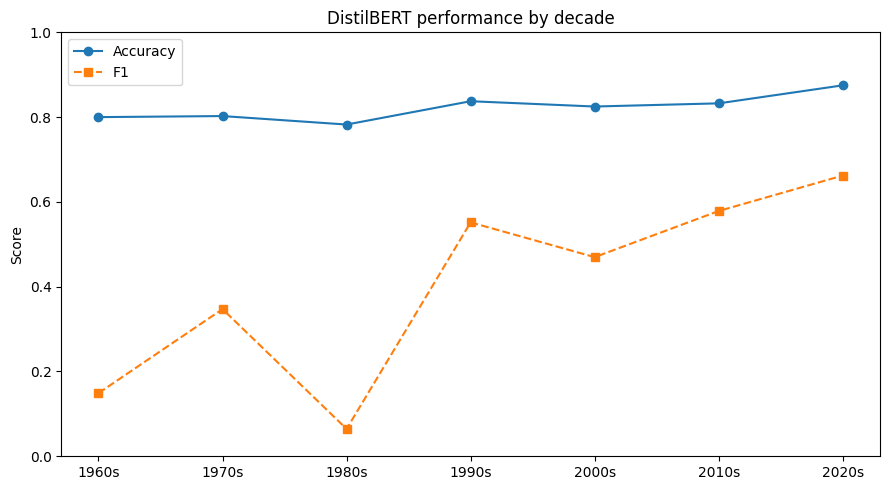

In [ ]:
import matplotlib.pyplot as plt

decades  = list(results.keys())
accuracy = [results[d]['eval_accuracy'] for d in decades]
f1       = [results[d]['eval_f1'] for d in decades]

plt.figure(figsize=(9, 5))
plt.plot(decades, accuracy, marker='o', label='Accuracy')
plt.plot(decades, f1,       marker='s', linestyle='--', label='F1')
plt.ylim(0.0, 1.0)
plt.ylabel('Score')
plt.title('DistilBERT performance by decade')
plt.legend()
plt.tight_layout()
plt.show()